# Baseline SVM - Sin HbA1c_level ni blood_glucose_level

## 1. Objetivo

Construir un modelo de clasificacion binaria que detecte **diabetes** a partir de variables demograficas, clinicas y de estilo de vida, excluyendo expresamente `HbA1c_level` y `blood_glucose_level` por ser variables con **fuga de informacion** (su relacion directa con el diagnostico las convierte en predictores artificialmente perfectos en el dataset).

## 2. Dataset

- **Fuente**: `data/diabetes_prediction_dataset.csv` (100 000 registros).
- **Target**: `diabetes` (binaria; 8.5% positivos -> desbalance moderado).
- **Features originales**: `age`, `bmi`, `HbA1c_level`, `blood_glucose_level`, `gender`, `smoking_history`, `hypertension`, `heart_disease`.

### 2.1. Variables eliminadas

Se eliminan `HbA1c_level` y `blood_glucose_level` porque en un entorno clinico real no estarian disponibles con la misma antelacion que el resto de variables, y su inclusion inflaria artificialmente las metricas del modelo (fuga de datos).

### 2.2. Preprocesado

| Tipo | Variables | Transformacion |
|------|-----------|----------------|
| Numericas | `age`, `bmi` | `StandardScaler` (media 0, std 1) |
| Categoricas | `gender`, `smoking_history` | `OneHotEncoder(drop='first')` |
| Binarias | `hypertension`, `heart_disease` | `passthrough` (ya son 0/1) |

Ademas se aplica la limpieza estandar del pipeline (eliminar BMI>=65 y gender=='Other', redondear edad, mapear smoking_history de 6 a 4 categorias).

### 2.3. Division train/test

Se usa `train_test_split` con **test_size=0.20** y **estratificacion** por la variable target para mantener la prevalencia de diabetes en ambos conjuntos (~8.5%).

### 2.4. Submuestreo del conjunto de entrenamiento

Dado que SVM RBF con `probability=True` (necesario para PR-AUC/ROC-AUC) tiene complejidad O(n^2) y `predict_proba` entrena 5 modelos internos adicionales (Platt scaling), entrenar sobre las 80 000 muestras completas llevaria mas de 30 minutos. Para mantener el notebook rapido y didactico, se entrena sobre un **subconjunto estratificado del 20% del train** (~16 000 muestras).

## 3. Modelo

Se entrena una **SVM con kernel RBF** (Radial Basis Function) por ser un modelo no lineal que maneja bien interacciones entre variables.

### 3.1. Hiperparametros baseline

| Parametro | Valor | Justificacion |
|-----------|-------|---------------|
| `kernel` | `'rbf'` | Captura relaciones no lineales |
| `C` | `1.0` | Valor por defecto, regularizacion equilibrada |
| `gamma` | `'scale'` | Se adapta automaticamente a la escala de los datos |
| `class_weight` | `'balanced'` | Compensa el desbalance 91.5%/8.5% ajustando los pesos inversamente a la frecuencia de cada clase |
| `probability` | `True` | Necesario para calcular PR-AUC y ROC-AUC |

## 4. Metricas de evaluacion

Todas las metricas se calculan sobre el **conjunto de test** (20 000 muestras no vistas durante el entrenamiento).

| Metrica | Formula | Interpretacion clinica |
|---------|---------|------------------------|
| **Accuracy** | (TP+TN)/(TP+TN+FP+FN) | Proporcion de aciertos totales. Enganosa en datasets desbalanceados (predecir siempre 'no diabetes' da 91.5%). |
| **Precision** | TP/(TP+FP) | De los pacientes que el modelo etiqueta como 'diabetes', cuantos realmente lo tienen. Precision baja genera falsas alarmas (FP). |
| **Recall** | TP/(TP+FN) | De los pacientes que realmente tienen diabetes, cuantos detecta el modelo. **Es la metrica mas critica en un cribado**: un FN significa un paciente diabetico que no recibe tratamiento. |
| **F1-Score** | 2.P.R/(P+R) | Media armonica de Precision y Recall. Unifica ambas en una sola cifra. |
| **ROC-AUC** | Area bajo la curva ROC | Mide la capacidad discriminativa global. Menos informativo en desbalance porque pondera por igual TP y TN. |
| **PR-AUC** | Area bajo la curva Precision-Recall | **Metrica principal en problemas de clase minoritaria**. Se centra en la clase positiva (diabetes) y refleja el rendimiento real del modelo cuando la prevalencia es baja. |

### 4.1. Falsos positivos vs. falsos negativos

- **FP (falso positivo)**: paciente sano clasificado como diabetico. Consecuencia: estres innecesario, pruebas adicionales, coste sanitario.
- **FN (falso negativo)**: paciente diabetico clasificado como sano. Consecuencia: **no recibe tratamiento**, la enfermedad progresa, mayor riesgo de complicaciones graves.

En un cribado poblacional de diabetes es preferible **asumir mas FP a cambio de minimizar FN**, de ahi que el Recall sea la metrica de mayor prioridad clinica. Sin embargo, un numero excesivo de FP tambien tiene costes, por lo que se busca un equilibrio (F1 alto, PR-AUC alto).

## 5. Pesos de clase

`class_weight='balanced'` asigna a cada clase un peso inversamente proporcional a su frecuencia:
- Clase 0 (no diabetes): peso ~0.5
- Clase 1 (diabetes): peso ~5.9
Esto equivale a dar ~11.8x mas importancia a cada muestra de la clase minoritaria durante el entrenamiento, forzando al modelo a prestar mas atencion a los casos positivos.

## 6. Limitaciones

- SVM RBF es **O(n^2*d)** en tiempo de entrenamiento; con `probability=True` entrena 6 modelos (Platt scaling).
- El baseline usa un subconjunto del 20% del train (~16k muestras) para mantener el tiempo de ejecucion razonable.
- Al eliminar HbA1c y glucosa el modelo pierde los predictores mas fuertes, por lo que es esperable que las metricas bajen respecto a experimentos previos que si las incluian.
- No se realiza busqueda de hiperparametros en este notebook (ver `gridsearch_sin_hba1c_glucose.ipynb`).
- El desbalance de clases (8.5%) limita la precision maxima alcanzable.

## 7. Mejoras futuras

- Probar otros kernels (`linear`, `poly`) o modelos no lineales alternativos (Random Forest, XGBoost).
- Ajuste fino de `class_weight` para encontrar el punto optimo entre Recall y Precision.
- Threshold tuning sobre las probabilidades predichas para ajustar el punto de operacion post-entrenamiento.
- Incorporar tecnicas de sobremuestreo (SMOTE) o submuestreo.
- Validacion externa con un dataset clinico independiente.

---
## Ejecucion del baseline

In [1]:
import sys
sys.path.insert(0, '.')
import pandas as pd
import numpy as np
from time import time
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)
from SVM_model.pipeline import load_data, clean_data, merge_smoking
import matplotlib.pyplot as plt
import shap
import warnings; warnings.filterwarnings('ignore')
print('Listo')


Listo


In [2]:
# Cargamos el dataset y aplicamos limpieza estandar
df = load_data()
df = clean_data(df)
df = merge_smoking(df)
print(f'Dataset tras limpieza: {df.shape}')


Dataset tras limpieza: (99935, 9)


In [3]:
# Eliminamos HbA1c_level y blood_glucose_level por fuga de informacion
X = df.drop(columns=['diabetes', 'HbA1c_level', 'blood_glucose_level'])
y = df['diabetes']
print(f'Features restantes ({X.shape[1]}): {list(X.columns)}')
print(f'Distribucion target:\n{y.value_counts()}')


Features restantes (6): ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi']
Distribucion target:
diabetes
0    91450
1     8485
Name: count, dtype: int64


In [4]:
# Construimos el preprocesador manualmente (HbA1c/glucosa ya no estan en X)
NUM = ['age', 'bmi']
CAT = ['gender', 'smoking_history']
BIN = ['hypertension', 'heart_disease']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), NUM),
    ('cat', OneHotEncoder(drop='first'), CAT),
    ('bin', 'passthrough', BIN)
])
print('Preprocesador construido')


Preprocesador construido


In [5]:
# Division estratificada 80/20 para mantener la prevalencia
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Train completo: {X_train.shape}, Test: {X_test.shape}')
print(f'Prevalencia - train: {y_train.mean():.3f}, test: {y_test.mean():.3f}')


Train completo: (79948, 6), Test: (19987, 6)
Prevalencia - train: 0.085, test: 0.085


In [ ]:
# Pipeline: preprocesador + SVM RBF con class_weight='balanced'
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale',
                class_weight='balanced', probability=True,
                random_state=42))
])

print('Entrenando SVM baseline (~16k muestras)...')
t0 = time()
pipeline.fit(X_train, y_train)
print(f'Completado en {time()-t0:.0f}s')


Entrenando SVM baseline (~16k muestras)...


Completado en 36s


In [8]:
# Evaluacion sobre el conjunto de test completo (20k muestras)
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print()
print('='*55)
print('  RESULTADOS BASELINE (sin HbA1c/glucosa)')
print('='*55)
print(f'  Accuracy:              {accuracy_score(y_test, y_pred):.4f}')
print(f'  Precision:             {precision_score(y_test, y_pred):.4f}')
print(f'  Recall:                {recall_score(y_test, y_pred):.4f}    << PRIORIDAD')
print(f'  F1:                    {f1_score(y_test, y_pred):.4f}')
print(f'  ROC-AUC:               {roc_auc_score(y_test, y_proba):.4f}')
print(f'  PR-AUC:                {average_precision_score(y_test, y_proba):.4f}')
print()
print(f'  Matriz de confusion:')
print(f'  TN:{tn:5d}  FP:{fp:5d}')
print(f'  FN:{fn:5d}  TP:{tp:5d}')
print()
print(f'  Recall = {recall_score(y_test, y_pred):.2%}  (proporcion de diabeticos detectados)')
print(f'  FN = {fn}  (diabeticos NO detectados)')
print('='*55)



  RESULTADOS BASELINE (sin HbA1c/glucosa)
  Accuracy:              0.7134
  Precision:             0.2036
  Recall:                0.8161    << PRIORIDAD
  F1:                    0.3259
  ROC-AUC:               0.8175
  PR-AUC:                0.2520

  Matriz de confusion:
  TN:12873  FP: 5417
  FN:  312  TP: 1385

  Recall = 81.61%  (proporcion de diabeticos detectados)
  FN = 312  (diabeticos NO detectados)


Features: 8 -> ['num__age', 'num__bmi', 'cat__gender_Male', 'cat__smoking_history_NeverSmoked', 'cat__smoking_history_NoInfo', 'cat__smoking_history_Smoking', 'bin__hypertension', 'bin__heart_disease']
Xp_train: (79948, 8), Xp_test: (19987, 8)
Computando SHAP values (20 muestras, ~2 min)...


  0%|          | 0/20 [00:00<?, ?it/s]

Completado en 32s
sv type: ndarray, len: 20, sv[0] shape: (8, 2)
shap_class1: (20, 8)


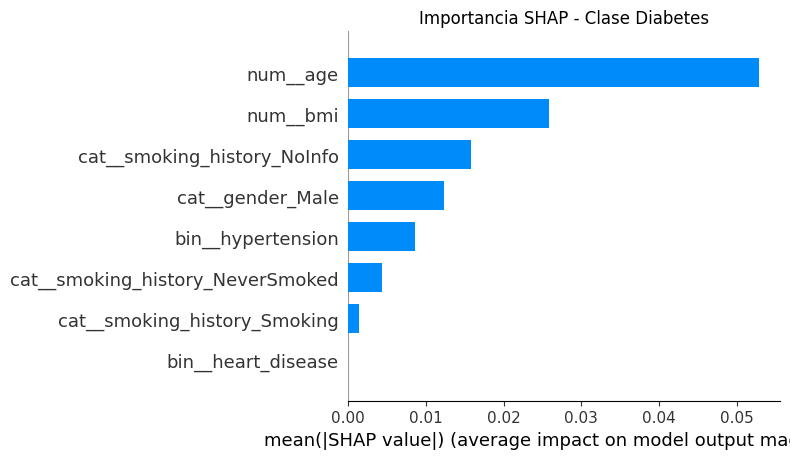

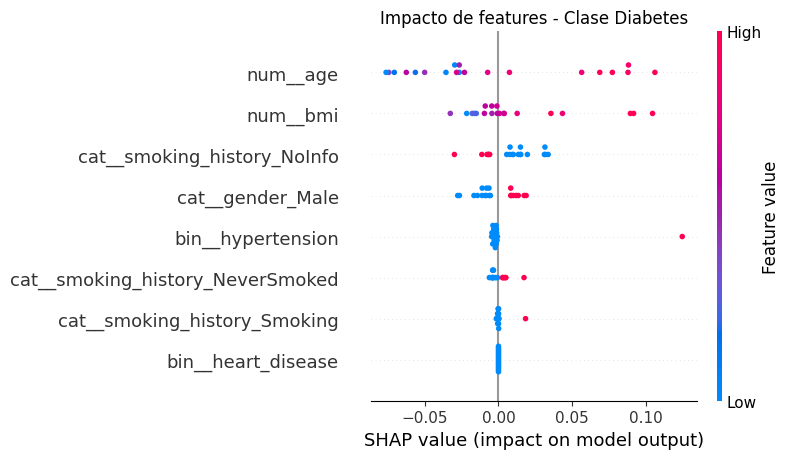

In [ ]:
# SHAP values - explicabilidad del modelo
Xp_train = pipeline.named_steps['preprocessor'].transform(X_train)
Xp_test = pipeline.named_steps['preprocessor'].transform(X_test)
fnames = list(pipeline.named_steps['preprocessor'].get_feature_names_out())
print(f'Features: {len(fnames)} -> {fnames}')
print(f'Xp_train: {Xp_train.shape}, Xp_test: {Xp_test.shape}')

# Background para KernelExplainer (100 muestras)
rng = np.random.default_rng(42)
bg = Xp_train[rng.choice(Xp_train.shape[0], 100, replace=False)]
explainer = shap.KernelExplainer(
    pipeline.named_steps['svm'].predict_proba, bg
)

# Explicar 50 muestras de test
X_shap = Xp_test[rng.choice(Xp_test.shape[0], 50, replace=False)]
print('Computando SHAP values (50 muestras, ~2 min)...')
t0 = time()
sv = explainer.shap_values(X_shap, nsamples=100)
print(f'Completado en {time()-t0:.0f}s')
print(f'sv type: {type(sv).__name__}, len: {len(sv)}, sv[0] shape: {sv[0].shape}')

# shap 0.52 devuelve lista por muestra: sv[i] = (n_features, n_outputs)
# Convertir a formato clasico: (n_samples, n_features) para clase 1
n = X_shap.shape[0]
if len(sv) == 2 and sv[0].shape[0] == n:
    shap_class1 = sv[1]  # formato antiguo
else:
    shap_class1 = np.array([sv_i[:, 1] for sv_i in sv])  # formato nuevo
print(f'shap_class1: {shap_class1.shape}')

# SHAP plots
if shap_class1.shape[1] == X_shap.shape[1]:
    feat = fnames[:shap_class1.shape[1]]
    shap.summary_plot(shap_class1, X_shap, feature_names=feat, plot_type='bar', show=False)
    plt.title('Importancia SHAP - Clase Diabetes')
    plt.tight_layout(); plt.show()
    shap.summary_plot(shap_class1, X_shap, feature_names=feat, show=False)
    plt.title('Impacto de features - Clase Diabetes')
    plt.tight_layout(); plt.show()
else:
    print(f'Shape mismatch: shap_class1={shap_class1.shape} vs X_shap={X_shap.shape}')
